# Monod CME Model Demo

This notebook demonstrates the six two-modality (unspliced + spliced) CME models
available in the Monod package.  For each model we:

1. Explain the biological interpretation of the parameters.
2. Compute the steady-state probability mass function (PSS) on a grid.
3. Visualise the joint distribution and its marginals.

At the end we show a parameter-sensitivity sweep and a side-by-side model comparison.

All heavy lifting is handled automatically by the Rust / GPU backend — no extra
configuration needed.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('src', 'monod'))
os.chdir(os.path.join(os.path.dirname(os.path.abspath('')) if '__file__' in dir() else os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from cme_toolbox import CMEModel

# Check which backends are active
from cme_toolbox import _HAS_RUST, _HAS_GPU
os.makedirs('figures', exist_ok=True)
print(f'Rust backend : {_HAS_RUST}')
print(f'GPU  backend : {_HAS_GPU}')

Rust backend : True
GPU  backend : False


In [2]:
# ── Shared plotting helpers ──────────────────────────────────────────────────

def plot_joint_and_marginals(pss, title, param_str, cmap='Blues', save_path=None):
    """Plot joint PMF (heatmap) with marginals on the side axes."""
    fig = plt.figure(figsize=(6, 5))
    gs  = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                           hspace=0.05, wspace=0.05)
    ax_joint  = fig.add_subplot(gs[1, 0])
    ax_top    = fig.add_subplot(gs[0, 0], sharex=ax_joint)
    ax_right  = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    # joint
    im = ax_joint.imshow(pss.T, origin='lower', aspect='auto',
                         cmap=cmap, norm=mcolors.PowerNorm(gamma=0.4, vmin=0))
    ax_joint.set_xlabel('Unspliced count', fontsize=11)
    ax_joint.set_ylabel('Spliced count',   fontsize=11)

    # marginals
    marg_u = pss.sum(axis=1)
    marg_s = pss.sum(axis=0)
    ax_top.plot(marg_u, color='steelblue', lw=1.5)
    ax_top.fill_between(range(len(marg_u)), marg_u, alpha=0.3, color='steelblue')
    ax_top.set_ylabel('P(u)', fontsize=9)
    ax_right.plot(marg_s, range(len(marg_s)), color='salmon', lw=1.5)
    ax_right.fill_betweenx(range(len(marg_s)), marg_s, alpha=0.3, color='salmon')
    ax_right.set_xlabel('P(s)', fontsize=9)

    # decorations
    plt.setp(ax_top.get_xticklabels(),   visible=False)
    plt.setp(ax_right.get_yticklabels(), visible=False)
    fig.suptitle(f'{title}\n{param_str}', fontsize=11, y=1.01)
    plt.colorbar(im, ax=[ax_joint, ax_right], label='Probability', shrink=0.8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def eval_pss(model_name, p_log, limits=(60, 80)):
    """Convenience: create model, evaluate, return PSS array."""
    model = CMEModel(model_name, 'None')
    return model.eval_model_pss(np.array(p_log), list(limits))

---
## 1 · Constitutive model

Transcription occurs at a **constant rate** $\alpha$.  The log-PGF is

$$\phi(g) = \frac{\alpha}{\beta}\,g_u + \frac{\alpha}{\gamma}\,g_s$$

giving **independent Poisson** marginals for unspliced ($u$) and spliced ($s$) counts.

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| `p[0]`    | $\log_{10}\beta$ | unspliced degradation rate |
| `p[1]`    | $\log_{10}\gamma$ | spliced degradation / splicing rate |

Mean unspliced = $\alpha/\beta$, mean spliced = $\alpha/\gamma$.

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_94808/4277292963.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


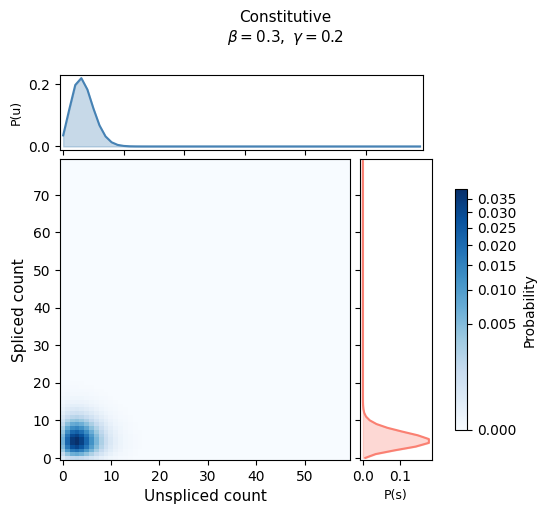

In [3]:
# beta=0.3, gamma=0.2  →  Poisson means ≈ 10 and 15
p_constitutive = [np.log10(0.3), np.log10(0.2)]
pss = eval_pss('Constitutive', p_constitutive)
plot_joint_and_marginals(
    pss, 'Constitutive',
    r'$\beta=0.3,\ \gamma=0.2$'
)

---
## 2 · Bursty model

Transcription occurs in **bursts** of geometrically-distributed size $b$.
The log-PGF integrates the burst-generating function along the ODE characteristics:

$$\phi(g) = \int_0^T \frac{b\,U(\tau,g)}{1 - b\,U(\tau,g)}\,d\tau$$

The marginals are **negative-binomial-like**, with heavier tails than the Constitutive
model at the same mean.

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| `p[0]`    | $\log_{10}b$ | mean burst size |
| `p[1]`    | $\log_{10}\beta$ | unspliced degradation rate |
| `p[2]`    | $\log_{10}\gamma$ | spliced degradation / splicing rate |

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_94808/4277292963.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


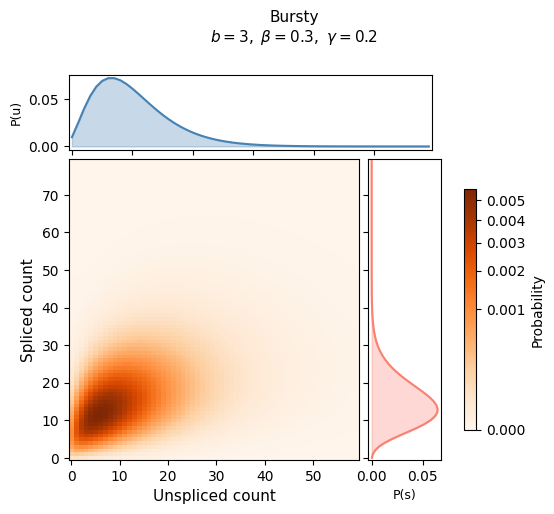

In [4]:
# b=3, beta=0.3, gamma=0.2
p_bursty = [np.log10(3), np.log10(0.3), np.log10(0.2)]
pss = eval_pss('Bursty', p_bursty)
plot_joint_and_marginals(
    pss, 'Bursty',
    r'$b=3,\ \beta=0.3,\ \gamma=0.2$',
    cmap='Oranges'
)

---
## 3 · CIR model

The Cox–Ingersoll–Ross (CIR) model is driven by an **inverse-Gaussian process**.
The integrand replaces $U/(1-U)$ with $(1-\sqrt{1-4U})/2$, yielding
**heavier tails** than the Bursty model.

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| `p[0]`    | $\log_{10}b$ | burst size analogue |
| `p[1]`    | $\log_{10}\beta$ | unspliced degradation rate |
| `p[2]`    | $\log_{10}\gamma$ | spliced degradation / splicing rate |

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_94808/4277292963.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


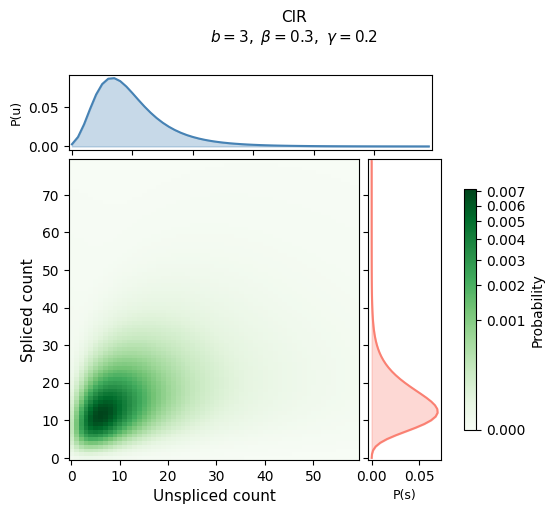

In [5]:
# Same parameters as Bursty for direct comparison
p_cir = [np.log10(3), np.log10(0.3), np.log10(0.2)]
pss = eval_pss('CIR', p_cir)
plot_joint_and_marginals(
    pss, 'CIR',
    r'$b=3,\ \beta=0.3,\ \gamma=0.2$',
    cmap='Greens'
)

---
## 4 · Extrinsic noise model

The transcription rate $k$ is **Gamma-distributed** (extrinsic noise), giving
a **negative-binomial** unspliced marginal and a correlated spliced distribution.

$$\phi(g) = -\alpha\,\ln\!\left(1 - \frac{g_u}{\beta} - \frac{g_s}{\gamma}\right)$$

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| `p[0]`    | $\log_{10}\alpha$ | shape of the Gamma rate distribution |
| `p[1]`    | $\log_{10}\beta$  | unspliced degradation rate |
| `p[2]`    | $\log_{10}\gamma$ | spliced degradation / splicing rate |

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_94808/4277292963.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


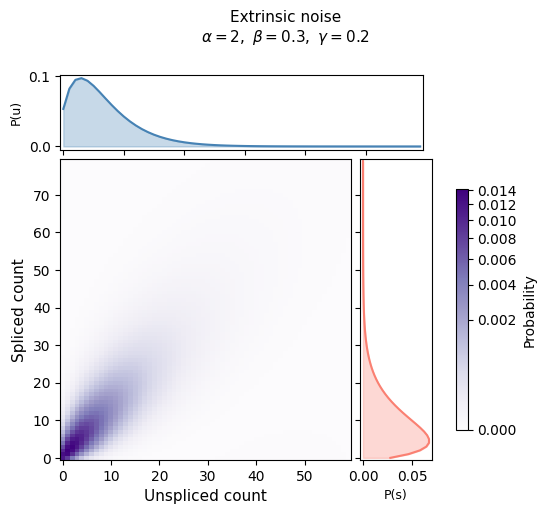

In [6]:
# alpha=2, beta=0.3, gamma=0.2
p_extrinsic = [np.log10(2), np.log10(0.3), np.log10(0.2)]
pss = eval_pss('Extrinsic', p_extrinsic)
plot_joint_and_marginals(
    pss, 'Extrinsic noise',
    r'$\alpha=2,\ \beta=0.3,\ \gamma=0.2$',
    cmap='Purples'
)

---
## 5 · Delay model

Bursty production with a **degradation delay** $\tau$ for unspliced RNA — a simple
model of co-transcriptional processing.

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| `p[0]`    | $\log_{10}b$         | mean burst size |
| `p[1]`    | $\log_{10}\beta$     | unspliced degradation rate |
| `p[2]`    | $\log_{10}\tau^{-1}$ | inverse delay (= splicing rate) |

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_94808/4277292963.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


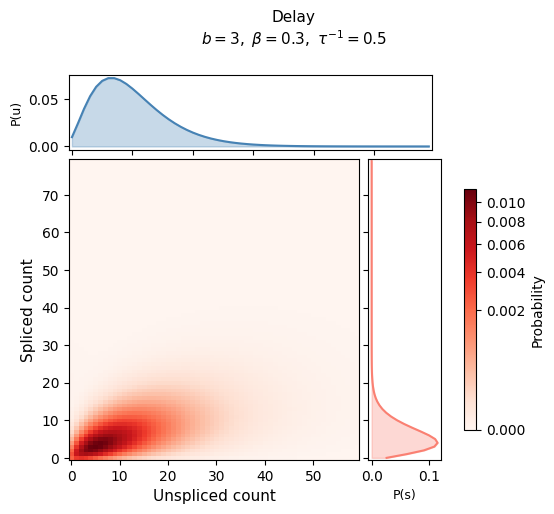

In [7]:
# b=3, beta=0.3, tauinv=0.5  (delay tau=2)
p_delay = [np.log10(3), np.log10(0.3), np.log10(0.5)]
pss = eval_pss('Delay', p_delay)
plot_joint_and_marginals(
    pss, 'Delay',
    r'$b=3,\ \beta=0.3,\ \tau^{-1}=0.5$',
    cmap='Reds'
)

---
## 6 · Delayed Splicing model

Bursty production where **splicing itself is delayed** by $\tau$, so unspliced RNA
accumulates before being converted to spliced.

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| `p[0]`    | $\log_{10}b$         | mean burst size |
| `p[1]`    | $\log_{10}\tau^{-1}$ | inverse splicing delay |
| `p[2]`    | $\log_{10}\gamma$    | spliced degradation rate |

/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_94808/4277292963.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


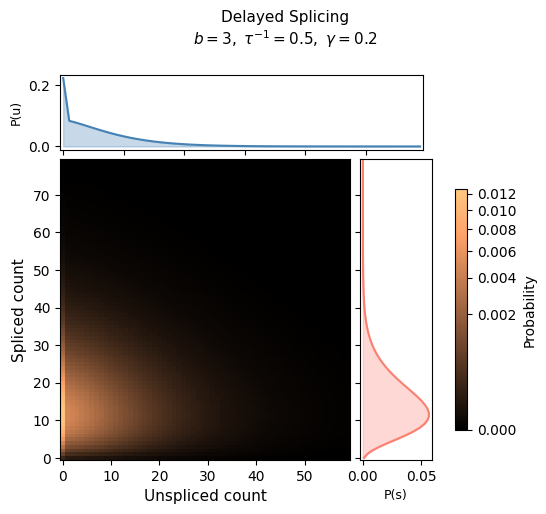

In [8]:
# b=3, tauinv=0.5, gamma=0.2
p_ds = [np.log10(3), np.log10(0.5), np.log10(0.2)]
pss = eval_pss('DelayedSplicing', p_ds)
plot_joint_and_marginals(
    pss, 'Delayed Splicing',
    r'$b=3,\ \tau^{-1}=0.5,\ \gamma=0.2$',
    cmap='copper'
)

---
## 7 · Parameter sensitivity — Bursty burst size

Increasing the mean burst size $b$ (with fixed $\beta$ and $\gamma$) increases
variance while keeping the mean approximately constant, broadening the marginals.

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


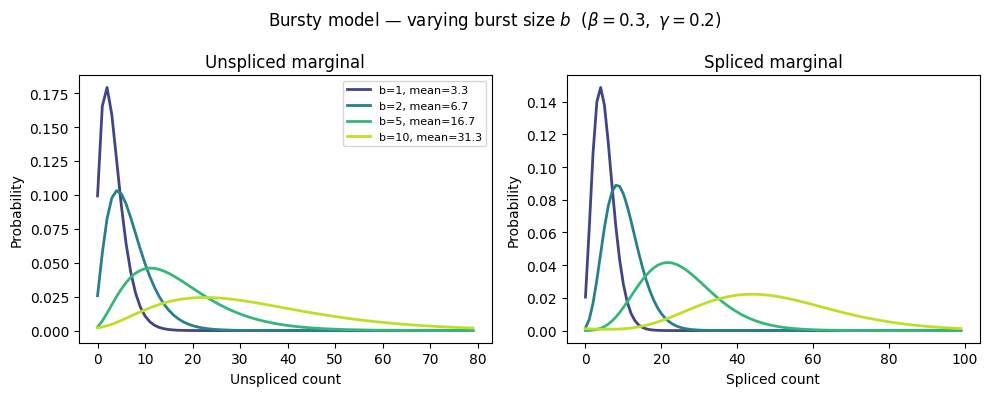

In [9]:
burst_sizes = [1, 2, 5, 10]
beta, gamma = 0.3, 0.2
model = CMEModel('Bursty', 'None')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(burst_sizes)))

for b, col in zip(burst_sizes, colors):
    p = np.array([np.log10(b), np.log10(beta), np.log10(gamma)])
    pss = model.eval_model_pss(p, [80, 100])
    marg_u = pss.sum(axis=1)
    marg_s = pss.sum(axis=0)
    mean_u = (np.arange(len(marg_u)) * marg_u).sum()
    axes[0].plot(marg_u, color=col, lw=2, label=f'b={b}, mean={mean_u:.1f}')
    axes[1].plot(marg_s, color=col, lw=2, label=f'b={b}')

axes[0].set_xlabel('Unspliced count'); axes[0].set_ylabel('Probability')
axes[0].set_title('Unspliced marginal'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('Spliced count');   axes[1].set_ylabel('Probability')
axes[1].set_title('Spliced marginal')
fig.suptitle(r'Bursty model — varying burst size $b$  ($\beta=0.3,\ \gamma=0.2$)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/models_burst_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8 · Model comparison at matched moments

All five three-parameter models are evaluated at the same values of $b$, $\beta$,
and $\gamma$ (or the analogue parameters), so differences reflect the noise
architecture rather than just parameter magnitudes.

We compare the **unspliced marginal** for Bursty, CIR, Extrinsic, Delay, and
Delayed Splicing.

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'uns

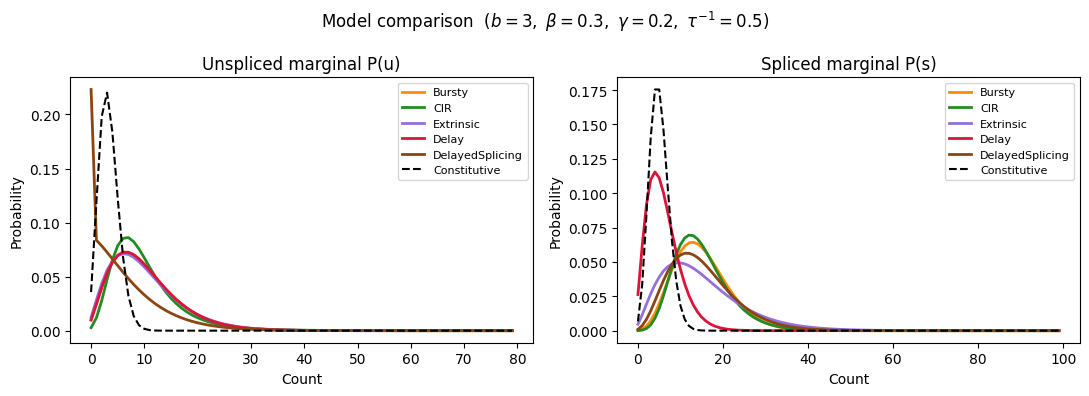

In [10]:
b, beta, gamma, tauinv = 3.0, 0.3, 0.2, 0.5
configs = {
    'Bursty':          [np.log10(b),    np.log10(beta), np.log10(gamma)],
    'CIR':             [np.log10(b),    np.log10(beta), np.log10(gamma)],
    'Extrinsic':       [np.log10(b),    np.log10(beta), np.log10(gamma)],
    'Delay':           [np.log10(b),    np.log10(beta), np.log10(tauinv)],
    'DelayedSplicing': [np.log10(b),    np.log10(tauinv), np.log10(gamma)],
}
colors_map = {
    'Bursty': 'darkorange', 'CIR': 'forestgreen',
    'Extrinsic': 'mediumpurple', 'Delay': 'crimson',
    'DelayedSplicing': 'saddlebrown',
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for name, p_log in configs.items():
    pss   = eval_pss(name, p_log, limits=(80, 100))
    marg_u = pss.sum(axis=1)
    marg_s = pss.sum(axis=0)
    col = colors_map[name]
    axes[0].plot(marg_u, color=col, lw=2, label=name)
    axes[1].plot(marg_s, color=col, lw=2, label=name)

# Also add Constitutive for reference (matched mean)
alpha_eff = b * beta   # alpha/beta = b  →  alpha = b*beta
p_const = [np.log10(alpha_eff / beta), np.log10(gamma)]  # note: Constitutive p=(beta,gamma)
# For Constitutive the synthesis rate is implicit; use beta=alpha_eff, gamma=gamma
model_c = CMEModel('Constitutive', 'None')
pss_c   = model_c.eval_model_pss(np.array([np.log10(beta), np.log10(gamma)]), [80, 100])
axes[0].plot(pss_c.sum(axis=1), 'k--', lw=1.5, label='Constitutive')
axes[1].plot(pss_c.sum(axis=0), 'k--', lw=1.5, label='Constitutive')

for ax, title in zip(axes, ['Unspliced marginal P(u)', 'Spliced marginal P(s)']):
    ax.set_xlabel('Count'); ax.set_ylabel('Probability')
    ax.set_title(title); ax.legend(fontsize=8)

fig.suptitle(
    r'Model comparison  ($b=3,\ \beta=0.3,\ \gamma=0.2,\ \tau^{-1}=0.5$)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('figures/models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9 · Timing comparison

Quick benchmark to confirm the Rust / GPU backend is active.

In [11]:
import time

model_b = CMEModel('Bursty', 'None')
p = np.array([np.log10(3), np.log10(0.3), np.log10(0.2)])
limits = [80, 120]

# Warm-up
_ = model_b.eval_model_pss(p, limits)

N = 20
t0 = time.perf_counter()
for _ in range(N):
    model_b.eval_model_pss(p, limits)
elapsed = (time.perf_counter() - t0) / N * 1000

backend = 'GPU' if _HAS_GPU else ('Rust' if _HAS_RUST else 'Python')
grid = limits[0] * (limits[1] // 2 + 1)
print(f'Backend  : {backend}')
print(f'Grid     : {limits[0]} × {limits[1]}  ({grid} points)')
print(f'Mean time: {elapsed:.2f} ms  (average over {N} calls)')

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
Backend  : Rust
Grid     : 80 × 120  (4880 points)
Mean time: 0.92 ms  (average over 20 calls)


---
## 10 · Fitting to real single-cell data

The sections below walk through a complete inference pipeline on the bundled
`example_adata.h5ad` dataset (~66 k cells, gene **PTPRC**):

1. **Load** the AnnData object and inspect the raw counts.
2. **Preprocess** with `extract_data` — computes moments, histogram, and grid limits.
3. **Method-of-Moments (MoM)** — closed-form parameter estimates; fast but approximate.
4. **Gradient-descent optimisation** — minimise KL-divergence to get the best fit.

Cells  : 65,988
Genes  : 1
Layers : ['ambiguous', 'mature', 'nascent', 'protein', 'spliced', 'unspliced']

Gene   : PTPRC
Unspliced  — mean 1.42, max 71
Spliced    — mean 0.62, max 34


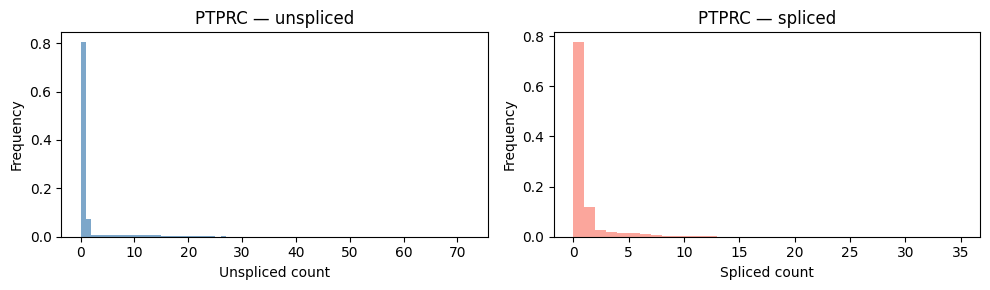

In [12]:
import anndata as ad

EXAMPLE_PATH = os.path.join('example_h5ad', 'example_adata.h5ad')
raw_adata = ad.read_h5ad(EXAMPLE_PATH)

print(f'Cells  : {raw_adata.n_obs:,}')
print(f'Genes  : {raw_adata.n_vars}')
print(f'Layers : {list(raw_adata.layers.keys())}')
print()

# Pick PTPRC (well-expressed gene used in the test suite)
gene = 'PTPRC'
idx  = list(raw_adata.var_names).index(gene)
u    = raw_adata.layers['unspliced'][:, idx]
s    = raw_adata.layers['spliced'][:, idx]
if hasattr(u, 'toarray'):
    u = u.toarray().ravel()
    s = s.toarray().ravel()
else:
    u = np.asarray(u).ravel()
    s = np.asarray(s).ravel()

print(f'Gene   : {gene}')
print(f'Unspliced  — mean {u.mean():.2f}, max {int(u.max())}')
print(f'Spliced    — mean {s.mean():.2f}, max {int(s.max())}')

# Raw marginal histograms
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(u, bins=range(int(u.max()) + 2), color='steelblue', alpha=0.7, density=True)
axes[0].set_xlabel('Unspliced count'); axes[0].set_ylabel('Frequency')
axes[0].set_title(f'{gene} — unspliced')
axes[1].hist(s, bins=range(int(s.max()) + 2), color='salmon', alpha=0.7, density=True)
axes[1].set_xlabel('Spliced count');   axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{gene} — spliced')
plt.savefig('figures/models_data_distribution.png', dpi=150, bbox_inches='tight')
plt.tight_layout(); plt.show()

### 10.2 · Preprocessing with `extract_data`

`extract_data` filters genes by expression level, computes empirical moments
(mean, variance, cross-covariance), builds the unique-histogram representation of
the joint count distribution, and chooses grid limits **M** (max count + padding)
for the probability grid.

We fit a **Bursty** model here — the most commonly used splicing-aware noise model.

In [13]:
import sys
sys.path.insert(0, os.path.join('src', 'monod'))
from extract_data import extract_data

# Build model and preprocess the data
bio_model = 'Bursty'
fit_model = CMEModel(bio_model, 'None')

proc_adata = extract_data(
    raw_adata,
    fit_model,
    dataset_name='demo_bursty',
    n_genes=1,           # select the top 1 gene (PTPRC)
    viz=False,
    hist_type='unique',
)

# Grid limits chosen by extract_data (max count + padding per modality)
M = proc_adata.uns['M'][:, 0].tolist()   # [unspliced_limit, spliced_limit]
print(f'Grid limits M = {M}  (unspliced × spliced)')

# Empirical moments stored in proc_adata.var
mom_cols = [c for c in proc_adata.var.columns if c.startswith('MOM_')]
print('\nEmpirical moments:')
for col in mom_cols:
    print(f'  {col:35s} = {float(proc_adata.var[col].values[0]):.4f}')

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
is sparse
1 genes retained after expression filter.
Grid limits M = [81, 44]  (unspliced × spliced)

Empirical moments:
  MOM_unspliced_mean                  = 1.4201
  MOM_unspliced_var                   = 19.7019
  MOM_spliced_mean                    = 0.6208
  MOM_spliced_var                     = 3.0108
  MOM_cov_unspliced_spliced           = 6.2683


### 10.3 · Method-of-Moments (MoM) initial estimates

`get_MoM` uses the empirical moments to solve for model parameters analytically.
This is fast (~µs) and gives a reasonable starting point, but may not be optimal
because it only uses low-order statistics.

MoM parameter estimates (log₁₀ scale):
  log₁₀ b = 1.110  →  12.8737
  log₁₀ β = 0.957  →  9.0654
  log₁₀ γ = 1.317  →  20.7365
KL-divergence at MoM: 0.1216


/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_94808/2972845304.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


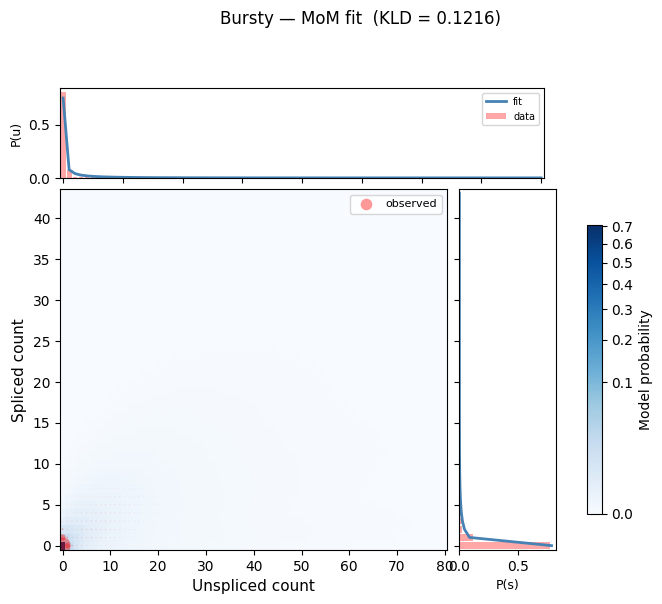

In [14]:
def moments_dict(adata):
    return {col: float(adata.var[col].values[0])
            for col in adata.var.columns if col.startswith('MOM_')}

moments = moments_dict(proc_adata)
lb = np.array(fit_model.bio_bounds['phys_lb'])
ub = np.array(fit_model.bio_bounds['phys_ub'])

# get_MoM returns log10 parameter vector
p_mom = fit_model.get_MoM(moments, lb, ub, samp=np.zeros(2))

param_names = {
    'Bursty': ['log₁₀ b', 'log₁₀ β', 'log₁₀ γ'],
}.get(bio_model, [f'p[{i}]' for i in range(len(p_mom))])

print('MoM parameter estimates (log₁₀ scale):')
for name, val in zip(param_names, p_mom):
    print(f'  {name} = {val:.3f}  →  {10**val:.4f}')

# Unpack histogram from serialized uns (use searchdata_from_adata to deserialize)
import sys as _sys
_sys.path.insert(0, os.path.join('src', 'monod'))
from inference import searchdata_from_adata
_sd = searchdata_from_adata(proc_adata)
coords, freqs = _sd.hist[0]

pss_mom = fit_model.eval_model_pss(p_mom, M)
kld_mom = fit_model.eval_model_kld(p_mom, M, None, (coords, freqs), 'unique')
print(f'KL-divergence at MoM: {kld_mom:.4f}')


def plot_fit(pss, title, coords, freqs, M):
    """Overlay observed scatter on top of fitted PSS heatmap, with marginals."""
    fig = plt.figure(figsize=(8, 6))
    gs  = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                           hspace=0.05, wspace=0.05)
    ax_j = fig.add_subplot(gs[1, 0])
    ax_t = fig.add_subplot(gs[0, 0], sharex=ax_j)
    ax_r = fig.add_subplot(gs[1, 1], sharey=ax_j)

    # fitted PSS heatmap
    im = ax_j.imshow(pss.T, origin='lower', aspect='auto', cmap='Blues',
                     norm=mcolors.PowerNorm(gamma=0.4, vmin=0),
                     extent=[-0.5, M[0]-0.5, -0.5, M[1]-0.5])

    # observed data scatter (unique histogram points, size ∝ frequency)
    sc = ax_j.scatter(coords[:, 0], coords[:, 1],
                      s=freqs * 200, c='red', alpha=0.4, linewidths=0,
                      label='observed')
    ax_j.set_xlabel('Unspliced count', fontsize=11)
    ax_j.set_ylabel('Spliced count',   fontsize=11)
    ax_j.legend(fontsize=8, loc='upper right')

    # marginals
    marg_u_fit  = pss.sum(axis=1)
    marg_s_fit  = pss.sum(axis=0)
    obs_u = np.zeros(M[0]); obs_s = np.zeros(M[1])
    for (cu, cs), f in zip(coords, freqs):
        if cu < M[0]: obs_u[int(cu)] += f
        if cs < M[1]: obs_s[int(cs)] += f
    ax_t.plot(marg_u_fit, color='steelblue', lw=2, label='fit')
    ax_t.bar(range(M[0]), obs_u, color='red', alpha=0.35, label='data')
    ax_t.set_ylabel('P(u)', fontsize=9); ax_t.legend(fontsize=7)
    ax_r.plot(marg_s_fit, range(M[1]), color='steelblue', lw=2)
    ax_r.barh(range(M[1]), obs_s, color='red', alpha=0.35)
    ax_r.set_xlabel('P(s)', fontsize=9)

    plt.setp(ax_t.get_xticklabels(), visible=False)
    plt.setp(ax_r.get_yticklabels(), visible=False)
    fig.suptitle(title, fontsize=12, y=1.01)
    plt.colorbar(im, ax=[ax_j, ax_r], label='Model probability', shrink=0.8)
    plt.savefig('figures/models_mom_estimates.png', dpi=150, bbox_inches='tight')
    plt.tight_layout(); plt.show()


plot_fit(pss_mom,
         f'Bursty — MoM fit  (KLD = {kld_mom:.4f})',
         coords, freqs, M)

### 10.4 · Gradient-descent optimisation

We minimise the KL-divergence between the model PSS and the observed histogram
using `scipy.optimize.minimize` (L-BFGS-B with parameter bounds).  The objective
is the same function Monod uses internally during full inference.

Starting from the MoM estimates typically converges in < 50 evaluations.

In [15]:
from scipy.optimize import minimize

n_evals = [0]

def objective(p_log):
    n_evals[0] += 1
    return fit_model.eval_model_kld(p_log, M, None, (coords, freqs), 'unique')

# Bounds: use physical bounds from the model
bounds = list(zip(lb, ub))

result = minimize(
    objective,
    x0=p_mom,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 200, 'ftol': 1e-10, 'gtol': 1e-6},
)

p_opt = result.x
kld_opt = result.fun
print(f'Optimisation {"succeeded" if result.success else "stopped"} '
      f'after {n_evals[0]} KLD evaluations')
print(f'\nOptimised parameter estimates (log₁₀ scale):')
for name, val_m, val_o in zip(param_names, p_mom, p_opt):
    print(f'  {name}: MoM = {val_m:.3f}  →  opt = {val_o:.3f}  (Δ = {val_o - val_m:+.3f})')
print(f'\nKLD  MoM → opt:  {kld_mom:.5f}  →  {kld_opt:.5f}  '
      f'(improvement {kld_mom - kld_opt:.5f})')

Optimisation succeeded after 36 KLD evaluations

Optimised parameter estimates (log₁₀ scale):
  log₁₀ b: MoM = 1.110  →  opt = 1.092  (Δ = -0.018)
  log₁₀ β: MoM = 0.957  →  opt = 0.959  (Δ = +0.001)
  log₁₀ γ: MoM = 1.317  →  opt = 1.290  (Δ = -0.026)

KLD  MoM → opt:  0.12156  →  0.12105  (improvement 0.00051)


/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_94808/2972845304.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


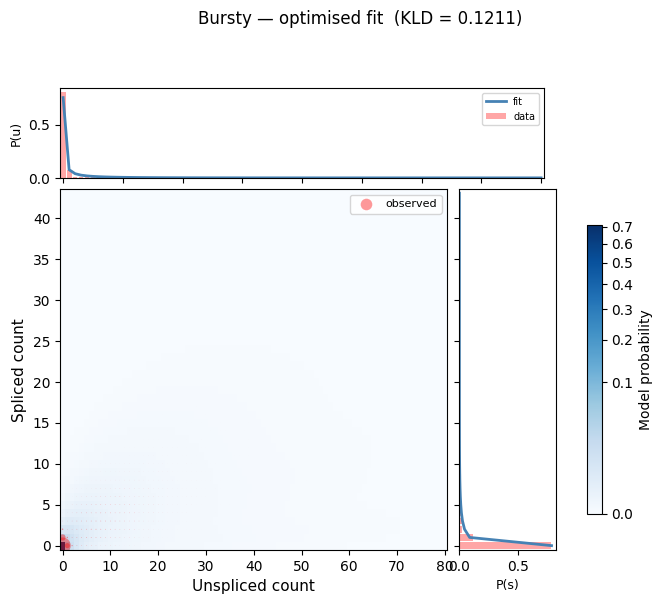

In [16]:
pss_opt = fit_model.eval_model_pss(p_opt, M)
plot_fit(pss_opt,
         f'Bursty — optimised fit  (KLD = {kld_opt:.4f})',
         coords, freqs, M)

### 10.5 · MoM vs optimised — side-by-side marginal comparison

A direct comparison of the two fits on the marginals makes the improvement
(or confirmation) from optimisation easy to see.

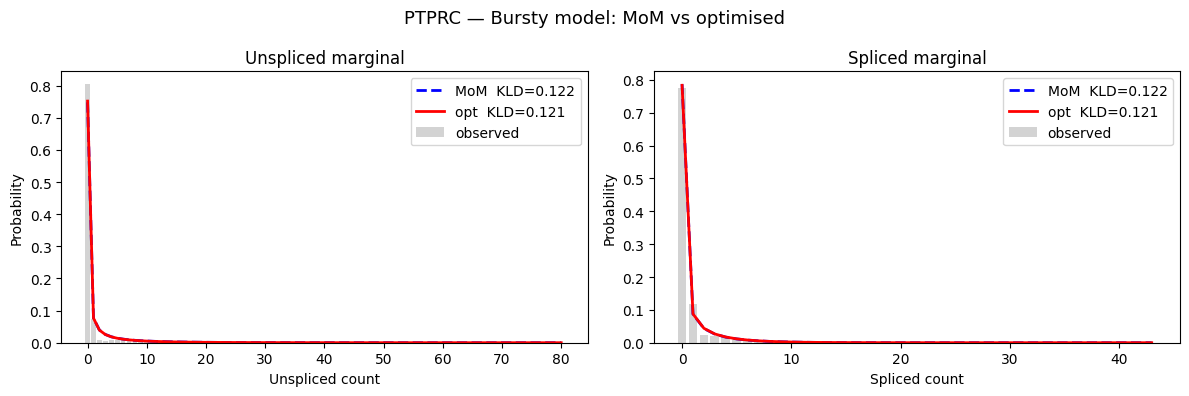

In [17]:
# Build empirical marginals from the unique histogram
obs_u = np.zeros(M[0]); obs_s = np.zeros(M[1])
for (cu, cs), f in zip(coords, freqs):
    if int(cu) < M[0]: obs_u[int(cu)] += f
    if int(cs) < M[1]: obs_s[int(cs)] += f

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Unspliced marginal
axes[0].bar(range(M[0]), obs_u, color='lightgrey', label='observed', zorder=1)
axes[0].plot(pss_mom.sum(axis=1), 'b--', lw=2, label=f'MoM  KLD={kld_mom:.3f}')
axes[0].plot(pss_opt.sum(axis=1), 'r-',  lw=2, label=f'opt  KLD={kld_opt:.3f}')
axes[0].set_xlabel('Unspliced count'); axes[0].set_ylabel('Probability')
axes[0].set_title('Unspliced marginal'); axes[0].legend()

# Spliced marginal
axes[1].bar(range(M[1]), obs_s, color='lightgrey', label='observed', zorder=1)
axes[1].plot(pss_mom.sum(axis=0), 'b--', lw=2, label=f'MoM  KLD={kld_mom:.3f}')
axes[1].plot(pss_opt.sum(axis=0), 'r-',  lw=2, label=f'opt  KLD={kld_opt:.3f}')
axes[1].set_xlabel('Spliced count'); axes[1].set_ylabel('Probability')
axes[1].set_title('Spliced marginal'); axes[1].legend()

fig.suptitle(f'PTPRC — Bursty model: MoM vs optimised', fontsize=13)
plt.savefig('figures/models_mom_vs_opt.png', dpi=150, bbox_inches='tight')
plt.tight_layout(); plt.show()

---
## 12 · Full inference pipeline — Bursty model

The sections above use `scipy.optimize.minimize` directly on a single gene.
The `inference` module provides a higher-level pipeline that:

1. Wraps gene data into a **`SearchData`** object
2. Defines a **`InferenceParameters`** object (parameter bounds, optimiser settings)
3. Sweeps over a grid of technical-noise parameters via **`fit_all_grid_points`**
4. Selects the sampling optimum with **`find_sampling_optimum`**
5. Exposes fitted parameters, KLD values, and built-in visualisation tools

This mirrors how `perform_inference` works internally, but keeps each step
visible for inspection.

In [18]:
import re
from inference import InferenceParameters, searchdata_from_adata

# ── 12.1  Load and preprocess ────────────────────────────────────────────────
raw_adata = ad.read_h5ad(EXAMPLE_PATH)
bursty = CMEModel('Bursty', 'None')

monod_adata = extract_data(
    raw_adata, bursty,
    dataset_name='bursty_full_demo',
    n_genes=1,
    viz=False,
    hist_type='unique',
)
print(f"Genes retained: {monod_adata.n_vars}")
print(f"Cells: {monod_adata.n_obs}")

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
is sparse
1 genes retained after expression filter.
Genes retained: 1
Cells: 65988


### 12.2 · Build `SearchData`

`searchdata_from_adata` collects the count histograms, grid limits, and
cell moments into a single object that the inference machinery can iterate over.

In [19]:
search_data = searchdata_from_adata(monod_adata)

print(f"Genes:  {search_data.n_genes}")
print(f"Cells:  {search_data.n_cells}")
print(f"Limits (unspliced, spliced):")
for i, name in enumerate(search_data.gene_names):
    print(f"  {name}: {search_data.M[:, i].tolist()}")

Genes:  1
Cells:  65988
Limits (unspliced, spliced):
  PTPRC: [81, 44]


### 12.3 · Configure `InferenceParameters`

`InferenceParameters` sets the parameter search bounds and optimiser options.
With `seq_model='None'` there are no technical-noise parameters, so the
sampling grid collapses to a single point.

In [20]:
os.makedirs('bursty_full_demo', exist_ok=True)

inf_params = InferenceParameters(
    dataset_string='bursty_full_demo',
    model=bursty,
    use_lengths=False,          # no gene-length correction (no transcriptome file)
    gradient_params={
        'max_iterations': 100,
        'init_pattern': 'moments',  # start from MoM estimate
        'num_restarts': 3,          # try 3 random restarts
    },
)

print(f"Biological parameter bounds:")
for name, lb, ub in zip(bursty.param_str,
                         inf_params.phys_lb, inf_params.phys_ub):
    print(f"  {name}: [{lb:.1f}, {ub:.1f}]  (log10)")
print(f"Sampling grid size: {inf_params.gridsize}  →  {inf_params.n_grid_points} point(s)")

Biological parameter bounds:
  $\log_{10} b$: [-1.0, 4.2]  (log10)
  $\log_{10} \beta$: [-1.8, 2.5]  (log10)
  $\log_{10} \gamma$: [-1.8, 3.5]  (log10)
Sampling grid size: [1, 1]  →  1 point(s)


### 12.4 · Fit all grid points

`fit_all_grid_points` runs gradient descent for every gene at every grid point,
then aggregates results into a **`SearchResults`** object.
`find_sampling_optimum` picks the grid point with the lowest total KLD across
genes — here there is only one point so it's trivially selected.

In [21]:
import time

t0 = time.perf_counter()
search_result = inf_params.fit_all_grid_points(search_data)
search_result.find_sampling_optimum()
elapsed = time.perf_counter() - t0

print(f"Inference complete in {elapsed:.2f} s")
print(f"Optimal sampling parameters: {search_result.samp_optimum}")
print()

# Fitted biophysical parameters (log10 and linear)
import re
param_names = [re.sub(r'[$\\{}]|log_|10', '', s).strip() for s in bursty.param_str]
print("Fitted parameters:")
for gene, params in zip(search_data.gene_names, search_result.phys_optimum):
    vals_lin = 10**params
    pairs = ', '.join(f'{n}={v:.3f}' for n, v in zip(param_names, vals_lin))
    print(f"  {gene}: {pairs}")
print()
print(f"KL-divergence at optimum: {search_result.klds.squeeze():.5f}")

Grid scan: 100%|██████████| 1/1 [00:00<00:00,  5.93it/s]

Inference complete in 0.20 s
Optimal sampling parameters: (np.float64(0.0), np.float64(0.0))

Fitted parameters:
  PTPRC: b=12.359, beta=9.094, gamma=19.518

KL-divergence at optimum: 0.12105


### 12.5 · Visualise the fit

`SearchResults.plot_gene_distributions` overlays the model PSS on the observed
joint count histogram.  We also plot the two marginals (unspliced and spliced)
side-by-side with a manual comparison.

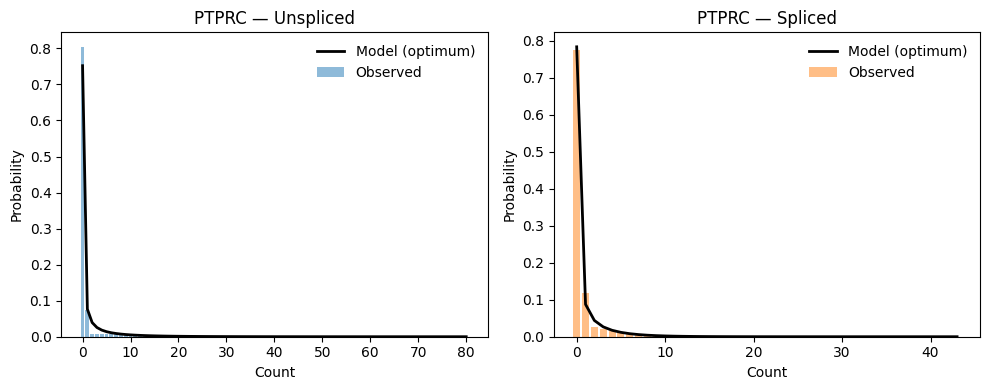

In [22]:
C = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ── Marginal comparison ──────────────────────────────────────────────────────
gene_idx = 0
lm = search_data.M[:, gene_idx]
pss_opt = bursty.eval_model_pss(
    search_result.phys_optimum[gene_idx], lm,
    samp=search_result.samp_optimum,
)
pss_u = pss_opt.sum(axis=1)   # unspliced marginal
pss_s = pss_opt.sum(axis=0)   # spliced marginal

obs_u = np.bincount(
    search_data.layers[0, :, gene_idx].astype(int),
    minlength=lm[0],
).astype(float)
obs_u /= obs_u.sum()

obs_s = np.bincount(
    search_data.layers[1, :, gene_idx].astype(int),
    minlength=lm[1],
).astype(float)
obs_s /= obs_s.sum()

fig, (ax_u, ax_s) = plt.subplots(1, 2, figsize=(10, 4))
for ax, obs, pss_m, label, color in [
    (ax_u, obs_u, pss_u, 'Unspliced', C[0]),
    (ax_s, obs_s, pss_s, 'Spliced',   C[1]),
]:
    ax.bar(np.arange(len(obs)), obs, color=color, alpha=0.5, label='Observed')
    ax.plot(np.arange(len(pss_m)), pss_m, 'k-', lw=2, label='Model (optimum)')
    ax.set_xlabel('Count'); ax.set_ylabel('Probability')
    ax.set_title(f'{search_data.gene_names[gene_idx]} — {label}')
    ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/models_inference_fit.png', dpi=150, bbox_inches='tight')
plt.show()

### 12.6 · KLD landscape

With multiple sampling-parameter grid points the KLD landscape shows which
technical-noise level best explains the data.  With `seq_model='None'` there
is a single point; this cell generalises to multi-point grids.

In [23]:
print("KLD per grid point per gene:")
print(search_result.klds)
print(f"\nTotal KLD at each grid point: {search_result.obj_func}")
print(f"Selected grid point index:    {search_result.samp_optimum_ind}")

param_lin = 10 ** search_result.phys_optimum[0]
b_opt, beta_opt, gamma_opt = param_lin
print(f"\nFinal fitted parameters for {search_data.gene_names[0]}:")
print(f"  Burst size  b     = {b_opt:.3f}")
print(f"  mRNA decay  β     = {beta_opt:.4f}  (half-life ≈ {np.log(2)/beta_opt:.1f} a.u.)")
print(f"  Splicing    γ     = {gamma_opt:.4f}  (half-life ≈ {np.log(2)/gamma_opt:.1f} a.u.)")

KLD per grid point per gene:
[[0.12105088]]

Total KLD at each grid point: [0.12105088]
Selected grid point index:    0

Final fitted parameters for PTPRC:
  Burst size  b     = 12.359
  mRNA decay  β     = 9.0940  (half-life ≈ 0.1 a.u.)
  Splicing    γ     = 19.5180  (half-life ≈ 0.0 a.u.)


---
## 13 · Gene-length bias correction  (`use_lengths`)

When sequencing captures RNA proportionally to gene length, the effective
Poisson capture rate λ for each gene is:

    λ_gene = λ_base × gene_length   (i.e.  log10 λ_gene = log10 λ_base + log10 gene_length)

Monod handles this automatically when:

* `adata.var["gene_length"]` (bp, linear scale) **or** `adata.var["log_lengths"]` (log₁₀) is
  present before `extract_data` is called, **and**
* `seq_model="Poisson"` and `use_lengths` is set on `InferenceParameters`.

The `use_lengths` parameter controls which sampling channels receive the offset:

| Value | Effect |
|-------|--------|
| `None` | No length correction (genome-wide sampling rate) |
| `"unspliced"` | Add `log₁₀(gene_length)` to the unspliced channel |
| `"spliced"` | Add `log₁₀(gene_length)` to the spliced channel |
| `"both"` | Add `log₁₀(gene_length)` to both channels |

`extract_data` auto-computes `log_lengths = log10(gene_length)` if only the linear
column is available.  The Rust fast path (`use_rust_lbfgsb=True`) applies the
per-gene offset entirely inside the rayon loop — no Python round-trip.


In [24]:
# ── 13.1  Attach synthetic gene lengths to the raw AnnData ───────────────
# In a real dataset these come from a GTF/BED file via a transcriptome helper.
# Here we assign plausible lengths (1000-10000 bp) so the demo is self-contained.
import numpy as np
import anndata as ad

raw_len = ad.read_h5ad(EXAMPLE_PATH)
rng = np.random.default_rng(42)
raw_len.var['gene_length'] = rng.integers(1000, 10000, size=raw_len.n_vars)

print('Gene lengths (first 5 genes):')
print(raw_len.var[['gene_length']].head())


Gene lengths (first 5 genes):
       gene_length
PTPRC         1803


In [25]:
# ── 13.2  Preprocess — extract_data auto-computes log_lengths ────────────
poisson_model = CMEModel('Bursty', 'Poisson')

monod_len = extract_data(
    raw_len, poisson_model,
    dataset_name='length_demo',
    n_genes=2,
    viz=False,
    hist_type='unique',
)

# extract_data automatically converts gene_length -> log_lengths
print('var columns:', monod_len.var.columns.tolist())
print(monod_len.var[['gene_length', 'log_lengths']].head())


The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
is sparse
1 genes retained after expression filter.
var columns: ['gene_id', 'Gene_symbol', 'overlap', 'n_cells', 'gene_length', 'log_lengths', 'gene_exp_filter', 'selected_genes', 'MOM_unspliced_mean', 'MOM_unspliced_var', 'MOM_spliced_mean', 'MOM_spliced_var', 'MOM_cov_unspliced_spliced']
       gene_length  log_lengths
PTPRC         1803     3.255996


In [ ]:
# ── 13.3  Run inference with gene-length bias correction ────────────────
import os, time
from inference import InferenceParameters, searchdata_from_adata

os.makedirs('length_demo', exist_ok=True)

search_data_len = searchdata_from_adata(monod_len)

inf_len = InferenceParameters(
    dataset_string='length_demo',
    model=poisson_model,
    use_lengths="unspliced",   # add log10(gene_length) to the unspliced sampling parameter
    gradient_params={
        'max_iterations': 100,
        'init_pattern': 'moments',
        'num_restarts': 2,
        'use_rust_lbfgsb': True,  # Rust rayon loop; lengths applied inside Rust
    },
)

print(f'Sampling grid: {inf_len.n_grid_points} point(s)')
print(f'use_lengths:   {inf_len.use_lengths}')
print(f'seq_model:     {poisson_model.seq_model}')

t0 = time.perf_counter()
result_len = inf_len.fit_all_grid_points(search_data_len)
result_len.find_sampling_optimum()
elapsed = time.perf_counter() - t0

print(f'\nInference complete in {elapsed:.2f} s')
print(f'Optimal sampling rate (log10 lambda_base): {result_len.samp_optimum}')
print('\nFitted parameters (log10):')
for gene, params in zip(search_data_len.gene_names, result_len.phys_optimum):
    print(f'  {gene}: {params}')
